# Implemantation with Pytorch

## Esential setup

First, install dependencies.

In [25]:
!pip install torch
!pip install -q torchinfo
!pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Import everything will need.

In [16]:
import torch
from torch import nn
from torchinfo import summary

## Load CSV

In [17]:
import pandas as pd

data = pd.read_csv("fer2013.csv")

## Define Transformations

In [20]:
from torchvision.transforms import ToTensor

# Define transformations
transform = ToTensor()

## Create Dataset & DataLoader

In [23]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

class Fer2013Dataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pixels = self.data.iloc[idx, 1].split(" ")
        pixels = [int(pixel) for pixel in pixels]
        pixels = np.array(pixels, dtype=np.uint8).reshape((48, 48))

        emotion = self.data.iloc[idx, 0]

        image = Image.fromarray(pixels)
        
        if self.transform:
            image = self.transform(image)

        return image, emotion

# Create the dataset
fer_dataset = Fer2013Dataset(data, transform=transform)

# Create the dataloader
BATCH_SIZE = 32
fer_dataloader = DataLoader(fer_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

## Visualize Images

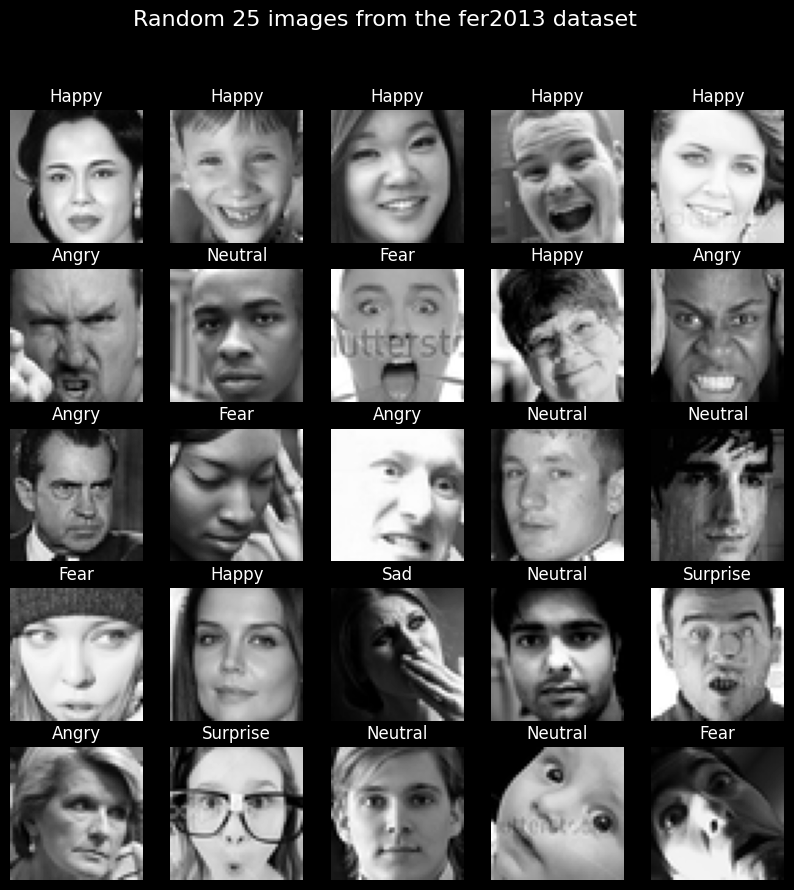

In [27]:
import matplotlib.pyplot as plt
import random

num_rows = 5
num_cols = num_rows

# Create a figure with subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(10, 10))

# Define emotion labels for annotation
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Iterate over the subplots and display random images from the fer2013 dataset
for i in range(num_rows):
    for j in range(num_cols):
        # Choose a random index from the fer2013 dataset
        index = random.randrange(len(fer_dataset))

        # Display the image in the subplot
        image, emotion = fer_dataset[index]
        axs[i, j].imshow(image.squeeze().numpy(), cmap='gray')

        # Set the title of the subplot as the corresponding emotion label
        axs[i, j].set_title(emotion_labels[int(emotion)], color="white")

        # Disable the axis for better visualization
        axs[i, j].axis(False)

# Set the super title of the figure
fig.suptitle(f"Random {num_rows * num_cols} images from the fer2013 dataset", fontsize=16, color="white")

# Set the background color of the figure as black
fig.set_facecolor(color='black')

# Display the plot
plt.show()